# 1: Loading the dataset:

In [1]:
import pandas as pd
df = pd.read_csv("Fish.csv")
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


# 2: EDA

In [2]:
df.shape

(159, 7)

In [3]:
df["Species"].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
df.describe()

,Weight,Length1,Length2,Length3,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,26.247170,28.415723,31.227044,8.970994,4.417486
std,357.978317,9.996441,10.716328,11.610246,4.286208,1.685804
min,0.000000,7.500000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,19.050000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,25.200000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,32.700000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,59.000000,63.400000,68.000000,18.957000,8.142000


In [6]:
df.isnull().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["Weight"].unique()[:50]

array([ 242.,  290.,  340.,  363.,  430.,  450.,  500.,  390.,  475.,
        600.,  700.,  610.,  650.,  575.,  685.,  620.,  680.,  725.,
        720.,  714.,  850., 1000.,  920.,  955.,  925.,  975.,  950.,
         40.,   69.,   78.,   87.,  120.,    0.,  110.,  150.,  145.,
        160.,  140.,  169.,  161.,  200.,  180.,  272.,  270.,  306.,
        540.,  800.,   55.,   60.,   90.])

### Their is a Weight=0 . We have to remove this because the fish cant have 0 weight.

In [9]:
df = df[df['Weight'] > 0].reset_index(drop=True)
print(f"\nDataset shape after removal: {df.shape}")
print("Remaining species counts:")
print(df['Species'].value_counts())


Dataset shape after removal: (158, 7)
Remaining species counts:
Species
Perch        56
Bream        35
Roach        19
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: count, dtype: int64


# 3:Visualization:

### Check multicollinearity between length variables:

Correlation between Length1, Length2, Length3:
         Length1  Length2  Length3
Length1   1.0000   0.9995   0.9920
Length2   0.9995   1.0000   0.9941
Length3   0.9920   0.9941   1.0000


C:\Users\Super\AppData\Local\Temp\ipykernel_5384\159924130.py:13: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  pd.plotting.scatter_matrix(df[['Length1', 'Length2', 'Length3']],
C:\Users\Super\AppData\Local\Temp\ipykernel_5384\159924130.py:22: UserWarning: tight_layout not applied: number of columns in subplot specifications must be multiples of one another.
  plt.tight_layout()


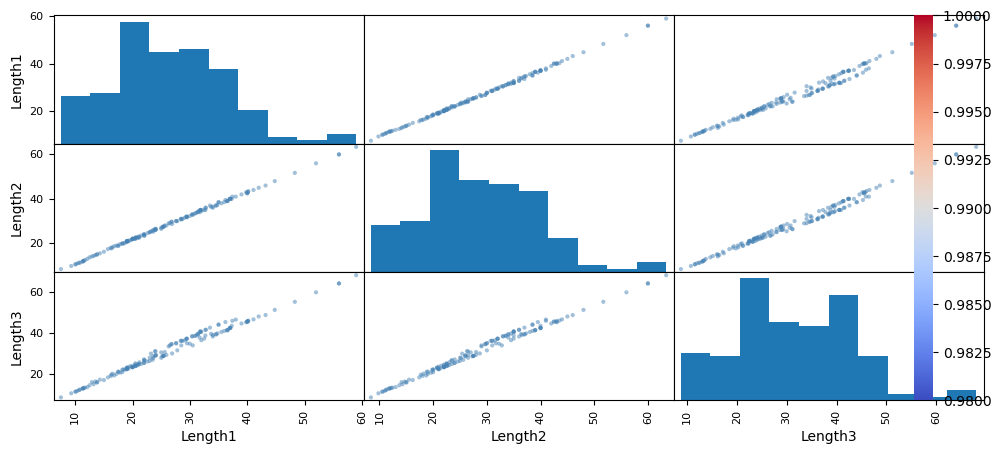

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
 

length_corr = df[['Length1', 'Length2', 'Length3']].corr()
print("Correlation between Length1, Length2, Length3:")
print(length_corr.round(4))
 

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pd.plotting.scatter_matrix(df[['Length1', 'Length2', 'Length3']],
                           ax=axes[0], diagonal='hist', color='steelblue', alpha=0.5)
axes[0].set_title('Fig 1: Scatter Matrix - Length Variables', fontsize=11)
 
# Heatmap of length correlations
sns.heatmap(length_corr, annot=True, fmt='.4f', cmap='coolwarm',
            vmin=0.98, vmax=1.0, ax=axes[1], square=True)
axes[1].set_title('Fig 2: Correlation Heatmap - Length Variables', fontsize=11)
 
plt.tight_layout()
plt.savefig('fig1_length_multicollinearity.png', dpi=150, bbox_inches='tight')
plt.show()

### As all lengths are higly correlated so we can keep only one length.

In [11]:
df =df.drop(columns=['Length1','Length2'])

In [17]:
df.head()

,Species,Weight,Length3,Height,Width
0,Bream,242.0,30.0,11.5200,4.0200
1,Bream,290.0,31.2,12.4800,4.3056
2,Bream,340.0,31.1,12.3778,4.6961
3,Bream,363.0,33.5,12.7300,4.4555
4,Bream,430.0,34.0,12.4440,5.1340


### Correlation heatmap of all remaining numeric variables

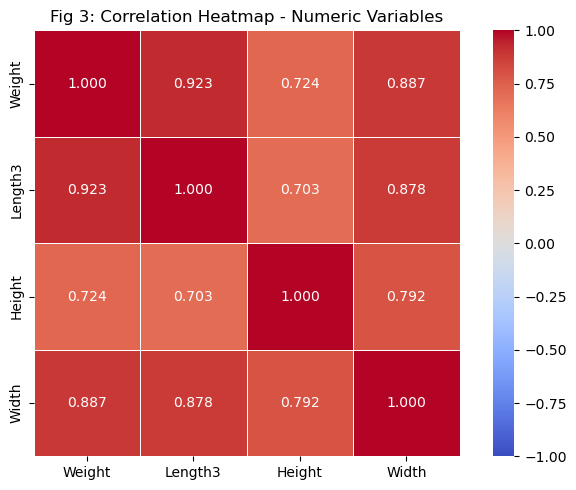

Correlations with Weight:
Weight     1.000000
Length3    0.923090
Width      0.886654
Height     0.723857
Name: Weight, dtype: float64


In [13]:
numeric_cols = ['Weight', 'Length3', 'Height', 'Width']
corr_matrix = df[numeric_cols].corr()
 
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title('Fig 3: Correlation Heatmap - Numeric Variables', fontsize=12)
plt.tight_layout()
plt.savefig('fig2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Correlations with Weight:")
print(corr_matrix['Weight'].sort_values(ascending=False))

### Distribution of Weight

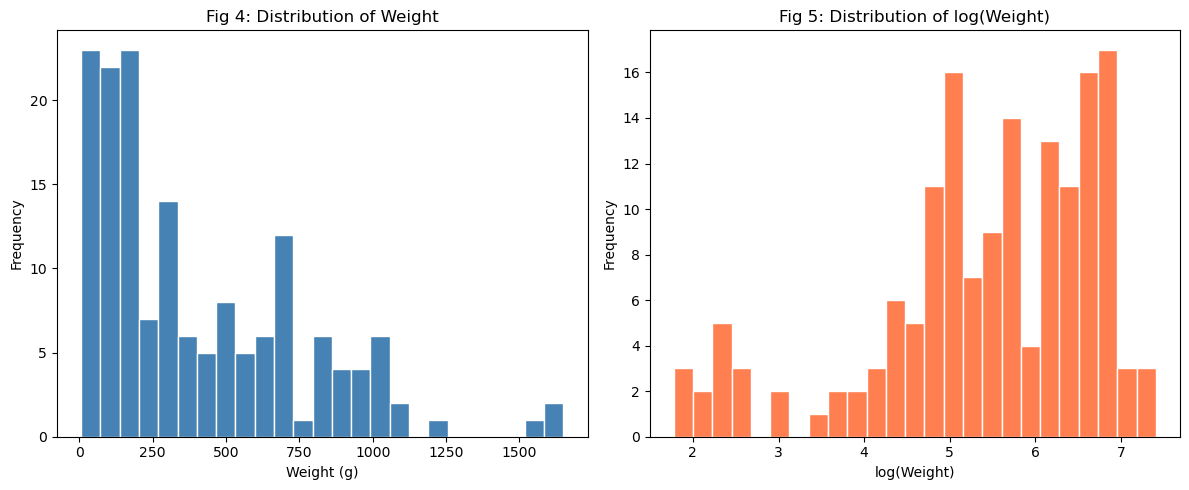

Weight is right-skewed. log(Weight) is more normally distributed.
This motivates the use of a logarithmic regression model.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Histogram - shows right skew
axes[0].hist(df['Weight'], bins=25, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Weight (g)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Fig 4: Distribution of Weight')
 
# Log-transformed weight - shows how log normalises the distribution
axes[1].hist(np.log(df['Weight']), bins=25, color='coral', edgecolor='white')
axes[1].set_xlabel('log(Weight)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Fig 5: Distribution of log(Weight)')
 
plt.tight_layout()
plt.savefig('fig3_weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
 
print("Weight is right-skewed. log(Weight) is more normally distributed.")
print("This motivates the use of a logarithmic regression model.")
 

### Scatter plots of Weight vs each predictor


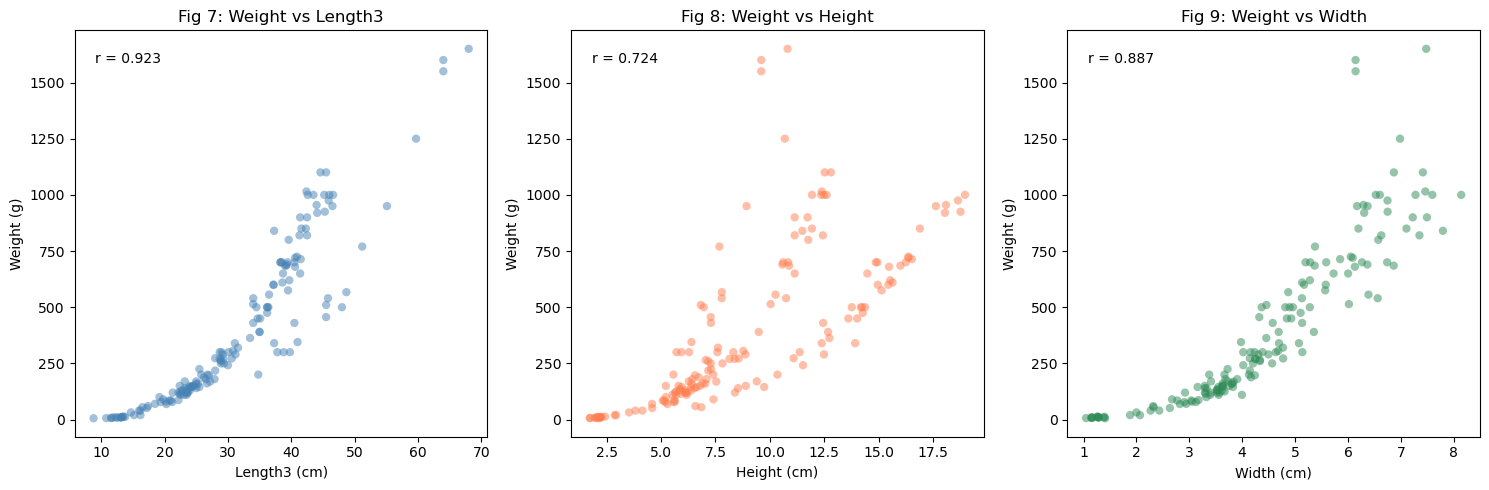

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
predictors = ['Length3', 'Height', 'Width']
colors = ['steelblue', 'coral', 'seagreen']
 
for i, (col, color) in enumerate(zip(predictors, colors)):
    axes[i].scatter(df[col], df['Weight'], alpha=0.5, color=color, edgecolors='none')
    axes[i].set_xlabel(f'{col} (cm)')
    axes[i].set_ylabel('Weight (g)')
    axes[i].set_title(f'Fig {7+i}: Weight vs {col}')
    # Add correlation annotation
    r = df[col].corr(df['Weight'])
    axes[i].annotate(f'r = {r:.3f}', xy=(0.05, 0.92), xycoords='axes fraction',
                     fontsize=10, color='black')
 
plt.tight_layout()
plt.savefig('fig5_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()
 

# 4: Building Models

### MODEL 1 - Simple Linear Regression


### We predict Weight using Length3, Height, Width and Species
### C(Species) tells the model that Species is a category (not a number)
 

In [19]:
import statsmodels.formula.api as smf        
import statsmodels.api as sm                 
from sklearn.metrics import mean_squared_error  

model1 = smf.ols('Weight ~ Length3 + Height + Width + C(Species)', data=df).fit()
 
# Print the results 
print(model1.summary())
 
# RMSE = how wrong our predictions are on average (in grams)
# Lower RMSE = better model
pred1 = model1.fittedvalues   # these are the model's predictions
rmse1 = np.sqrt(mean_squared_error(df['Weight'], pred1))
print(f"\nLinear Model RMSE: {rmse1:.2f} grams")
 

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.934
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     231.6
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.63e-82
Time:                        19:04:01   Log-Likelihood:                -938.31
No. Observations:                 158   AIC:                             1897.
Df Residuals:                     148   BIC:                             1927.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                -

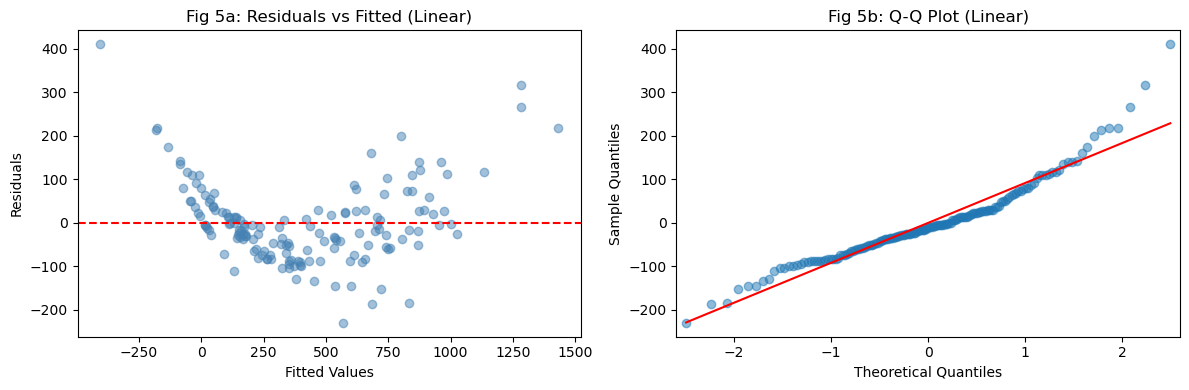

In [20]:

# Diagnostic plots help us check if the model is doing its job properly
residuals1 = model1.resid        
fitted1 = model1.fittedvalues   
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Plot 1: Residuals vs Fitted

axes[0].scatter(fitted1, residuals1, color='steelblue', alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Fig 5a: Residuals vs Fitted (Linear)')
 
# Plot 2: Q-Q plot

sm.qqplot(residuals1, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Fig 5b: Q-Q Plot (Linear)')
 
plt.tight_layout()
plt.savefig('fig5_linear_diagnostics.png', dpi=150)
plt.show()

### MODEL 2 - Linear Regression WITH Interactions

In [21]:
model2 = smf.ols(
    'Weight ~ Length3 + Height + Width + Length3:Height + Length3:Width + Height:Width + C(Species)',
    data=df
).fit()
 
print(model2.summary())
 
pred2 = model2.fittedvalues
rmse2 = np.sqrt(mean_squared_error(df['Weight'], pred2))
print(f"\nInteraction Model RMSE: {rmse2:.2f} grams")

                            OLS Regression Results                            
Dep. Variable:                 Weight   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     561.7
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          5.19e-115
Time:                        19:07:12   Log-Likelihood:                -847.71
No. Observations:                 158   AIC:                             1721.
Df Residuals:                     145   BIC:                             1761.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

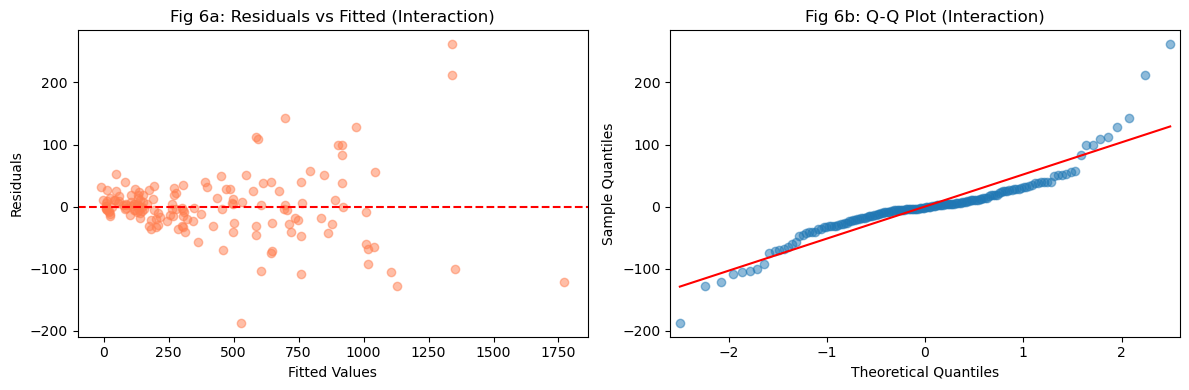

In [22]:
residuals2 = model2.resid
fitted2 = model2.fittedvalues
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].scatter(fitted2, residuals2, color='coral', alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Fig 6a: Residuals vs Fitted (Interaction)')
 
sm.qqplot(residuals2, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Fig 6b: Q-Q Plot (Interaction)')
 
plt.tight_layout()
plt.savefig('fig6_interaction_diagnostics.png', dpi=150)
plt.show()

### MODEL 3 - Logarithmic Regression

In [23]:
df['log_Weight']  = np.log(df['Weight'])
df['log_Length3'] = np.log(df['Length3'])
df['log_Height']  = np.log(df['Height'])
df['log_Width']   = np.log(df['Width'])
 
model3 = smf.ols(
    'log_Weight ~ log_Length3 + log_Height + log_Width + C(Species)',
    data=df
).fit()
 
print(model3.summary())
 

pred3_log    = model3.fittedvalues       # predictions
pred3_grams  = np.exp(pred3_log)         # convert back to grams
 
rmse3 = np.sqrt(mean_squared_error(df['Weight'], pred3_grams))
print(f"\nLog Model RMSE: {rmse3:.2f} grams")

                            OLS Regression Results                            
Dep. Variable:             log_Weight   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     3939.
Date:                Mon, 23 Mar 2026   Prob (F-statistic):          2.05e-171
Time:                        19:08:33   Log-Likelihood:                 164.84
No. Observations:                 158   AIC:                            -309.7
Df Residuals:                     148   BIC:                            -279.1
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

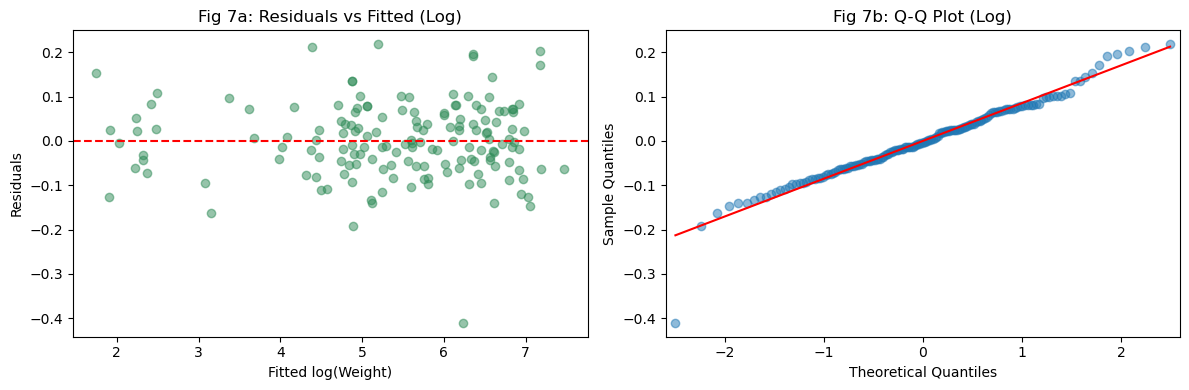

In [24]:
residuals3 = model3.resid
fitted3 = model3.fittedvalues
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
axes[0].scatter(fitted3, residuals3, color='seagreen', alpha=0.5)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_xlabel('Fitted log(Weight)')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Fig 7a: Residuals vs Fitted (Log)')
 
sm.qqplot(residuals3, line='s', ax=axes[1], alpha=0.5)
axes[1].set_title('Fig 7b: Q-Q Plot (Log)')
 
plt.tight_layout()
plt.savefig('fig7_log_diagnostics.png', dpi=150)
plt.show()

### Models Comparision

       MODEL COMPARISON (lower RMSE = better)
  Model 1 - Linear       RMSE: 91.81 g
  Model 2 - Interaction  RMSE: 51.74 g
  Model 3 - Logarithmic  RMSE: 50.70 g


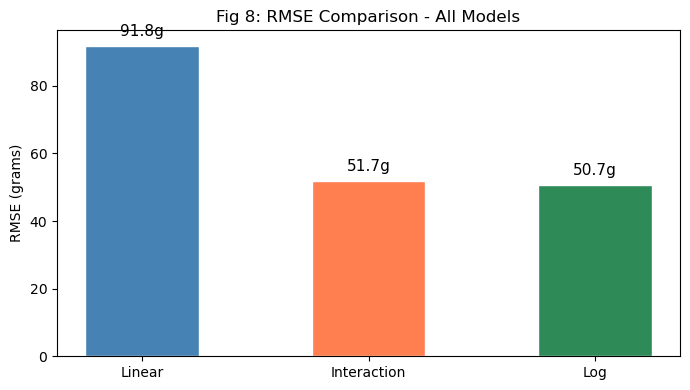

In [25]:
print("=" * 45)
print("       MODEL COMPARISON (lower RMSE = better)")
print("=" * 45)
print(f"  Model 1 - Linear       RMSE: {rmse1:.2f} g")
print(f"  Model 2 - Interaction  RMSE: {rmse2:.2f} g")
print(f"  Model 3 - Logarithmic  RMSE: {rmse3:.2f} g")
print("=" * 45)
 
# Bar chart to show the comparison visually
plt.figure(figsize=(7, 4))
models = ['Linear', 'Interaction', 'Log']
rmses  = [rmse1, rmse2, rmse3]
colors = ['steelblue', 'coral', 'seagreen']
 
bars = plt.bar(models, rmses, color=colors, edgecolor='white', width=0.5)
plt.ylabel('RMSE (grams)')
plt.title('Fig 8: RMSE Comparison - All Models')
 
# Add the RMSE number on top of each bar
for bar, val in zip(bars, rmses):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 3,
             f'{val:.1f}g',
             ha='center', fontsize=11)
 
plt.tight_layout()
plt.savefig('fig8_rmse_comparison.png', dpi=150)
plt.show()

# 5:Predict the Perch weight

In [26]:
 
# Use the best model (Model 3 - Log) to predict the weight of:
# Perch with Height=12.8cm, Width=6.9cm, Length3=41.9cm
 
# Step 1: Create a small dataframe with the fish's measurements
# We need to log-transform the inputs because the model was trained on log values
perch = pd.DataFrame({
    'log_Length3': [np.log(41.9)],
    'log_Height':  [np.log(12.8)],
    'log_Width':   [np.log(6.9)],
    'Species':     ['Perch']
})
 
# Step 2: Get the prediction (this comes out in log scale)
prediction_log = model3.predict(perch)
 
# Step 3: Convert from log scale back to grams
prediction_grams = np.exp(prediction_log)
 
print("=" * 45)
print("        PERCH WEIGHT PREDICTION")
print("=" * 45)
print(f"  Species  : Perch")
print(f"  Length3  : 41.9 cm")
print(f"  Height   : 12.8 cm")
print(f"  Width    : 6.9 cm")
print(f"  Model    : Logarithmic Regression")
print(f"  Predicted Weight: {float(prediction_grams):.2f} grams")
print("=" * 45)

        PERCH WEIGHT PREDICTION
  Species  : Perch
  Length3  : 41.9 cm
  Height   : 12.8 cm
  Width    : 6.9 cm
  Model    : Logarithmic Regression
  Predicted Weight: 907.62 grams


C:\Users\Super\AppData\Local\Temp\ipykernel_5384\1907534229.py:27: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print(f"  Predicted Weight: {float(prediction_grams):.2f} grams")
